### Data Cleaning and Master Dataset preparation

In [80]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

In [81]:
FILE_PATH = "C:/Users/KIIT/OneDrive/Desktop/BI_Assignment/data/bi_intern_assignment (2) (2) (1) (1) (1) (2) (3) (1) (1) (1).xlsx"

xls = pd.ExcelFile(FILE_PATH)

print(xls.sheet_names)

['📋 Cover', '📊 orders', '👤 customers', '🗂 product_catalog', '💰 product_pricing', '📝 SQL Tasks', '🐍 Python Task', '📈 LLM Dashboard']


In [82]:
## load tables from the sheets
orders = pd.read_excel(
    FILE_PATH,
    sheet_name="📊 orders"
)

customers = pd.read_excel(
    FILE_PATH,
    sheet_name="👤 customers"
)

product_catalog = pd.read_excel(
    FILE_PATH,
    sheet_name="🗂 product_catalog"
)

product_pricing = pd.read_excel(
    FILE_PATH,
    sheet_name="💰 product_pricing"
)

In [83]:
print("Orders:", orders.shape)
print("Customers:", customers.shape)
print("Product Catalog:", product_catalog.shape)
print("Product Pricing:", product_pricing.shape)

Orders: (52, 10)
Customers: (28, 6)
Product Catalog: (20, 7)
Product Pricing: (92, 3)


In [84]:
orders.tail()

,order_id,order_date,customer_id,city,state,category,product_name,quantity,channel,MRP
47,1048,2024-05-10,C101,Ahmedabad,GJ,Skincare,Night Cream,5.00,Instagram,"1,488.00"
48,1049,2024-08-08,C102,Pune,MH,Wellness,Collagen Supplement,3.00,Instagram,"1,453.00"
49,1050,2024-07-25,C122,Jaipur,RJ,Haircare,Hair Mask,4.00,App,"1,047.00"
50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
51,💡 PK: order_id | FK→customers: customer_id ...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [85]:
#clean dataset

orders["_order_id_numeric"] = pd.to_numeric(
    orders["order_id"],
    errors="coerce"
)

orders = orders[
    orders["_order_id_numeric"].notna()
].copy()

orders.drop(
    columns="_order_id_numeric",
    inplace=True
)

In [86]:
customers = customers[
    customers["customer_id"]
    .astype(str)
    .str.match(r"^C\d+$", na=False)
].copy()

In [87]:
product_catalog = product_catalog[
    pd.to_numeric(
        product_catalog["mrp"],
        errors="coerce"
    ).notna()
].copy()

In [88]:
product_pricing = product_pricing[
    pd.to_numeric(
        product_pricing["discount_pct"],
        errors="coerce"
    ).notna()
].copy()

In [89]:
#Standarize Data type
orders["order_id"] = pd.to_numeric(
    orders["order_id"]
).astype(int)

orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

orders["quantity"] = pd.to_numeric(
    orders["quantity"]
)

orders["MRP"] = pd.to_numeric(
    orders["MRP"]
)

orders["customer_id"] = orders[
    "customer_id"
].astype(str)

In [90]:
customers["customer_id"] = customers[
    "customer_id"
].astype(str)

customers["registration_date"] = pd.to_datetime(
    customers["registration_date"]
)

In [91]:
product_catalog["mrp"] = pd.to_numeric(
    product_catalog["mrp"]
)

product_catalog["cost_price"] = pd.to_numeric(
    product_catalog["cost_price"]
)

In [92]:
product_pricing["discount_pct"] = pd.to_numeric(
    product_pricing["discount_pct"]
)

In [93]:
print("Orders:", len(orders))
print("Customers:", len(customers))
print("Products:", len(product_catalog))
print("Pricing rows:", len(product_pricing))

Orders: 50
Customers: 26
Products: 18
Pricing rows: 90


In [94]:
#Validate primary rows
print(
    "Duplicate order IDs:",
    orders["order_id"].duplicated().sum()
)

print(
    "Duplicate customer IDs:",
    customers["customer_id"].duplicated().sum()
)

print(
    "Duplicate catalog keys:",
    product_catalog[
        ["category", "product_name"]
    ].duplicated().sum()
)

print(
    "Duplicate pricing keys:",
    product_pricing[
        ["product_name", "channel"]
    ].duplicated().sum()
)

Duplicate order IDs: 0
Duplicate customer IDs: 0
Duplicate catalog keys: 0
Duplicate pricing keys: 0


In [95]:
#validate foreign keys
missing_customers = orders[
    ~orders["customer_id"].isin(
        customers["customer_id"]
    )
]

print(
    "Orders with missing customers:",
    len(missing_customers)
)

Orders with missing customers: 0


In [96]:
product_keys = product_catalog[
    ["category", "product_name"]
].drop_duplicates()

order_product_check = orders.merge(
    product_keys,
    on=["category", "product_name"],
    how="left",
    indicator=True
)

print(
    "Orders with missing products:",
    (order_product_check["_merge"] == "left_only").sum()
)

Orders with missing products: 0


In [97]:
#validate pricing ref
pricing_check = orders.merge(
    product_pricing,
    on=["product_name", "channel"],
    how="left",
    indicator=True
)

print(
    "Orders with missing pricing:",
    (pricing_check["_merge"] == "left_only").sum()
)

Orders with missing pricing: 0


In [98]:
# Creating Master dataset
master_df = orders.merge(
    customers[
        [
            "customer_id",
            "customer_name",
            "customer_segment",
            "acquisition_channel",
            "is_loyalty_member"
        ]
    ],
    on="customer_id",
    how="left",
    validate="many_to_one"
)

In [99]:
validate="many_to_one"

In [100]:
master_df = master_df.merge(
    product_pricing,
    on=["product_name", "channel"],
    how="left",
    validate="many_to_one"
)

In [101]:
master_df = master_df.merge(
    product_catalog[
        [
            "category",
            "product_name",
            "brand",
            "cost_price",
            "shelf_life_days",
            "is_hero_product"
        ]
    ],
    on=["category", "product_name"],
    how="left",
    validate="many_to_one"
)

In [102]:
print(master_df.shape)

(50, 19)


In [103]:
print(master_df.columns.tolist())
print(master_df.isna().sum())
print(master_df.head(3).T)

['order_id', 'order_date', 'customer_id', 'city', 'state', 'category', 'product_name', 'quantity', 'channel', 'MRP', 'customer_name', 'customer_segment', 'acquisition_channel', 'is_loyalty_member', 'discount_pct', 'brand', 'cost_price', 'shelf_life_days', 'is_hero_product']
order_id               0
order_date             0
customer_id            0
city                   0
state                  0
category               0
product_name           0
quantity               0
channel                0
MRP                    0
customer_name          0
customer_segment       0
acquisition_channel    0
is_loyalty_member      0
discount_pct           0
brand                  0
cost_price             0
shelf_life_days        0
is_hero_product        0
dtype: int64
                                       0                    1  \
order_id                            1001                 1002   
order_date           2024-11-23 00:00:00  2024-10-29 00:00:00   
customer_id                         C103  

In [104]:
# METRIC ENGINEERING

# Gross transaction value before discount
master_df["gross_value"] = (
    master_df["quantity"] * master_df["MRP"]
)

# Discount amount
master_df["discount_amount"] = (
    master_df["gross_value"]
    * master_df["discount_pct"]
    / 100
)

# Net revenue after discount
master_df["revenue"] = (
    master_df["gross_value"]
    - master_df["discount_amount"]
)

In [105]:
master_df[
    [
        "order_id",
        "product_name",
        "quantity",
        "MRP",
        "discount_pct",
        "gross_value",
        "discount_amount",
        "revenue"
    ]
].head(10)

,order_id,product_name,quantity,MRP,discount_pct,gross_value,discount_amount,revenue
0,1001,Hair Mask,2.00,"1,047.00",12.00,"2,094.00",251.28,"1,842.72"
1,1002,Sunscreen SPF50,2.00,"1,442.00",20.00,"2,884.00",576.80,"2,307.20"
2,1003,Lipstick,4.00,955.00,5.00,"3,820.00",191.00,"3,629.00"
3,1004,Hair Mask,3.00,"1,047.00",12.00,"3,141.00",376.92,"2,764.08"
4,1005,Collagen Supplement,4.00,"1,453.00",12.00,"5,812.00",697.44,"5,114.56"
5,1006,Ashwagandha,2.00,"1,410.00",5.00,"2,820.00",141.00,"2,679.00"
6,1007,Face Wash,3.00,"1,215.00",0.00,"3,645.00",0.00,"3,645.00"
7,1008,Night Cream,2.00,"1,488.00",5.00,"2,976.00",148.80,"2,827.20"
8,1009,Conditioner,1.00,"1,395.00",10.00,"1,395.00",139.50,"1,255.50"
9,1010,Vitamin D3,4.00,"1,449.00",5.00,"5,796.00",289.80,"5,506.20"


In [106]:
# Total product cost
master_df["total_cost"] = (
    master_df["quantity"]
    * master_df["cost_price"]
)

# Gross profit
master_df["gross_profit"] = (
    master_df["revenue"]
    - master_df["total_cost"]
)

# Gross margin %
master_df["gross_margin_pct"] = np.where(
    master_df["revenue"] != 0,
    master_df["gross_profit"]
    / master_df["revenue"]
    * 100,
    0
)

In [107]:
print("FINAL DATA CHECK")

print("Number of orders:",
      master_df["order_id"].nunique())

print("Total units:",
      master_df["quantity"].sum())

print("Gross value:",
      master_df["gross_value"].sum())

print("Total discount:",
      master_df["discount_amount"].sum())

print("Net revenue:",
      master_df["revenue"].sum())

print("Total cost:",
      master_df["total_cost"].sum())

print("Gross profit:",
      master_df["gross_profit"].sum())

print("Average discount:",
      master_df["discount_pct"].mean())

FINAL DATA CHECK
Number of orders: 50
Total units: 151.0
Gross value: 200644.0
Total discount: 17287.14
Net revenue: 183356.86000000002
Total cost: 70985.98000000001
Gross profit: 112370.88
Average discount: 9.36


In [108]:
check = (
    master_df["gross_value"]
    - master_df["discount_amount"]
    - master_df["revenue"]
).abs().max()

print("Maximum revenue calculation error:", check)

Maximum revenue calculation error: 0.0


In [109]:
master_df.to_csv(
    "../output/master_dataset.csv",
    index=False
)

In [110]:
print("Number of orders:", master_df["order_id"].nunique())
print("Total units:", master_df["quantity"].sum())
print("Gross value:", master_df["gross_value"].sum())
print("Total discount:", master_df["discount_amount"].sum())
print("Net revenue:", master_df["revenue"].sum())
print("Total cost:", master_df["total_cost"].sum())
print("Gross profit:", master_df["gross_profit"].sum())
print("Average discount:", master_df["discount_pct"].mean())

Number of orders: 50
Total units: 151.0
Gross value: 200644.0
Total discount: 17287.14
Net revenue: 183356.86000000002
Total cost: 70985.98000000001
Gross profit: 112370.88
Average discount: 9.36


# Task1->SQL

In [111]:
import sqlite3

conn = sqlite3.connect(
    "../output/d2c_analysis.db"
)

In [112]:
orders.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

customers.to_sql(
    "customers",
    conn,
    if_exists="replace",
    index=False
)

product_catalog.to_sql(
    "product_catalog",
    conn,
    if_exists="replace",
    index=False
)

product_pricing.to_sql(
    "product_pricing",
    conn,
    if_exists="replace",
    index=False
)

90

In [113]:
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table';
    """,
    conn
)

print(tables)

              name
0           orders
1        customers
2  product_catalog
3  product_pricing


#### SQL_Q1: Customer Segment Analysis

In [114]:
qs1 = pd.read_sql_query(
    """
    SELECT
        c.customer_segment,
        COUNT(o.order_id) AS total_orders,
        AVG(o.MRP) AS avg_MRP
    FROM orders AS o
    JOIN customers AS c
        ON o.customer_id = c.customer_id
    GROUP BY c.customer_segment
    ORDER BY total_orders DESC;
    """,
    conn
)

qs1

,customer_segment,total_orders,avg_MRP
0,Gold,22,"1,327.64"
1,Silver,18,"1,282.11"
2,Bronze,10,"1,282.90"


#### SQL_Q 2: Product Revenue

In [115]:
qs2 = pd.read_sql_query(
    """
    SELECT
        o.product_name,
        SUM(
            o.quantity
            * o.MRP
            * (1 - p.discount_pct / 100.0)
        ) AS total_revenue
    FROM orders AS o
    JOIN product_pricing AS p
        ON o.product_name = p.product_name
        AND o.channel = p.channel
    GROUP BY o.product_name
    ORDER BY total_revenue DESC;
    """,
    conn
)

qs2

,product_name,total_revenue
0,Vitamin C Serum,"30,730.35"
1,Collagen Supplement,"20,429.18"
2,Conditioner,"14,298.75"
3,Ashwagandha,"14,100.00"
4,Night Cream,"13,540.80"
5,Moisturizer,"13,172.60"
6,Hair Mask,"12,145.20"
7,Vitamin D3,"10,751.58"
8,Eyeliner,"10,709.26"
9,Probiotic Blend,"10,605.76"


#### SQL_Q 3: Channel Discount

In [116]:
qs3 = pd.read_sql_query(
    """
    SELECT
        o.channel,
        COUNT(o.order_id) AS total_orders,
        AVG(p.discount_pct) AS avg_discount_pct
    FROM orders AS o
    JOIN product_pricing AS p
        ON o.product_name = p.product_name
        AND o.channel = p.channel
    GROUP BY o.channel
    ORDER BY avg_discount_pct DESC;
    """,
    conn
)

qs3

,channel,total_orders,avg_discount_pct
0,Amazon,7,17.43
1,Instagram,11,11.36
2,Website,8,9.25
3,WhatsApp,9,7.11
4,App,15,5.53


# Task2->Python
This section analyzes category-level performance using the cleaned and validated
master dataset. For each category, we calculate total revenue, number of orders,
and average order value (AOV).

In [117]:
required_columns = [
    "category",
    "order_id",
    "revenue"
]

missing_columns = [
    col for col in required_columns
    if col not in master_df.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("All required columns are available.")

All required columns are available.


In [118]:
## Calculate category level matrics
category_analysis = (
    master_df
    .groupby("category")
    .agg(
        total_revenue=("revenue", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

In [119]:
#Calculate AOV

category_analysis["AOV"] = (
    category_analysis["total_revenue"]
    / category_analysis["orders"]
)

In [120]:
category_analysis = category_analysis.sort_values(
    by="total_revenue",
    ascending=False
).reset_index(drop=True)

In [121]:
category_analysis

,category,total_revenue,orders,AOV
0,Wellness,"65,337.06",16,"4,083.57"
1,Skincare,"64,722.59",15,"4,314.84"
2,Haircare,"38,013.82",14,"2,715.27"
3,Makeup,"15,283.39",5,"3,056.68"


In [122]:
category_display = category_analysis.copy()

category_display["total_revenue"] = (
    category_display["total_revenue"]
    .round(2)
)

category_display["AOV"] = (
    category_display["AOV"]
    .round(2)
)

category_display

,category,total_revenue,orders,AOV
0,Wellness,"65,337.06",16,"4,083.57"
1,Skincare,"64,722.59",15,"4,314.84"
2,Haircare,"38,013.82",14,"2,715.27"
3,Makeup,"15,283.39",5,"3,056.68"


In [123]:
category_display["Revenue_Display"] = (
    category_display["total_revenue"]
    .map(lambda x: f"₹{x:,.2f}")
)

category_display["AOV_Display"] = (
    category_display["AOV"]
    .map(lambda x: f"₹{x:,.2f}")
)

category_display

,category,total_revenue,orders,AOV,Revenue_Display,AOV_Display
0,Wellness,"65,337.06",16,"4,083.57","₹65,337.06","₹4,083.57"
1,Skincare,"64,722.59",15,"4,314.84","₹64,722.59","₹4,314.84"
2,Haircare,"38,013.82",14,"2,715.27","₹38,013.82","₹2,715.27"
3,Makeup,"15,283.39",5,"3,056.68","₹15,283.39","₹3,056.68"


In [124]:
print(
    "Orders from category analysis:",
    category_analysis["orders"].sum()
)

print(
    "Orders in master dataset:",
    master_df["order_id"].nunique()
)

Orders from category analysis: 50
Orders in master dataset: 50


In [125]:
category_revenue = category_analysis[
    "total_revenue"
].sum()

overall_revenue = master_df[
    "revenue"
].sum()

print("Category revenue:", category_revenue)
print("Overall revenue:", overall_revenue)
print(
    "Difference:",
    abs(category_revenue - overall_revenue)
)

Category revenue: 183356.86
Overall revenue: 183356.86000000002
Difference: 2.9103830456733704e-11


In [126]:
# Create Category Controbution
category_analysis["revenue_share_pct"] = (
    category_analysis["total_revenue"]
    / category_analysis["total_revenue"].sum()
    * 100
)

In [127]:
category_analysis["revenue_share_pct"] = (
    category_analysis["revenue_share_pct"]
    .round(2)
)

In [128]:
## Generate Business Insight
top_revenue_category = category_analysis.loc[
    category_analysis["total_revenue"].idxmax()
]

print(
    "Highest revenue category:",
    top_revenue_category["category"]
)

print(
    "Revenue:",
    f"₹{top_revenue_category['total_revenue']:,.2f}"
)

Highest revenue category: Wellness
Revenue: ₹65,337.06


In [129]:
top_aov_category = category_analysis.loc[
    category_analysis["AOV"].idxmax()
]

print(
    "Highest AOV category:",
    top_aov_category["category"]
)

print(
    "AOV:",
    f"₹{top_aov_category['AOV']:,.2f}"
)

Highest AOV category: Skincare
AOV: ₹4,314.84


In [130]:
top_order_category = category_analysis.loc[
    category_analysis["orders"].idxmax()
]

print(
    "Highest order-volume category:",
    top_order_category["category"]
)

print(
    "Orders:",
    int(top_order_category["orders"])
)

Highest order-volume category: Wellness
Orders: 16


In [131]:
print("CATEGORY INSIGHTS")

print(
    f"Highest revenue category: "
    f"{top_revenue_category['category']} "
    f"with ₹{top_revenue_category['total_revenue']:,.2f} "
    f"in revenue."
)

print(
    f"Highest AOV category: "
    f"{top_aov_category['category']} "
    f"with an AOV of ₹{top_aov_category['AOV']:,.2f}."
)

print(
    f"Highest order-volume category: "
    f"{top_order_category['category']} "
    f"with {int(top_order_category['orders'])} orders."
)

CATEGORY INSIGHTS
Highest revenue category: Wellness with ₹65,337.06 in revenue.
Highest AOV category: Skincare with an AOV of ₹4,314.84.
Highest order-volume category: Wellness with 16 orders.


In [132]:
category_analysis["revenue_per_order"] = (
    category_analysis["total_revenue"]
    / category_analysis["orders"]
)

In [133]:
category_analysis.sort_values(
    "total_revenue",
    ascending=False
)

,category,total_revenue,orders,AOV,revenue_share_pct,revenue_per_order
0,Wellness,"65,337.06",16,"4,083.57",35.63,"4,083.57"
1,Skincare,"64,722.59",15,"4,314.84",35.30,"4,314.84"
2,Haircare,"38,013.82",14,"2,715.27",20.73,"2,715.27"
3,Makeup,"15,283.39",5,"3,056.68",8.34,"3,056.68"


In [134]:
category_analysis.sort_values(
    "AOV",
    ascending=False
)

,category,total_revenue,orders,AOV,revenue_share_pct,revenue_per_order
1,Skincare,"64,722.59",15,"4,314.84",35.30,"4,314.84"
0,Wellness,"65,337.06",16,"4,083.57",35.63,"4,083.57"
3,Makeup,"15,283.39",5,"3,056.68",8.34,"3,056.68"
2,Haircare,"38,013.82",14,"2,715.27",20.73,"2,715.27"


In [135]:
final_python_output = category_analysis[
    [
        "category",
        "total_revenue",
        "orders",
        "AOV"
    ]
].copy()

final_python_output

,category,total_revenue,orders,AOV
0,Wellness,"65,337.06",16,"4,083.57"
1,Skincare,"64,722.59",15,"4,314.84"
2,Haircare,"38,013.82",14,"2,715.27"
3,Makeup,"15,283.39",5,"3,056.68"


In [136]:
final_python_output = final_python_output.rename(
    columns={
        "category": "Category",
        "total_revenue": "Total Revenue",
        "orders": "Orders",
        "AOV": "Average Order Value"
    }
)

In [137]:
final_python_output

,Category,Total Revenue,Orders,Average Order Value
0,Wellness,"65,337.06",16,"4,083.57"
1,Skincare,"64,722.59",15,"4,314.84"
2,Haircare,"38,013.82",14,"2,715.27"
3,Makeup,"15,283.39",5,"3,056.68"


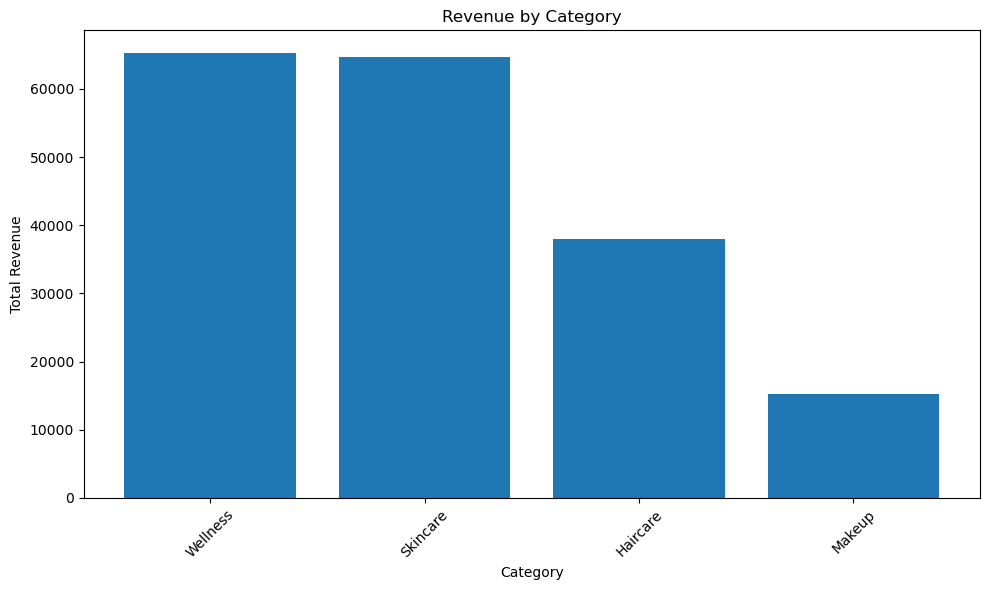

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    final_python_output["Category"],
    final_python_output["Total Revenue"]
)

plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.title("Revenue by Category")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Extra Analysis

In [138]:
# DASHBOARD FILTER / SELECTED SLICE

selected_category = "All"
selected_channel = "All"
selected_segment = "All"

filtered_df = master_df.copy()

if selected_category != "All":
    filtered_df = filtered_df[
        filtered_df["category"] == selected_category
    ]

if selected_channel != "All":
    filtered_df = filtered_df[
        filtered_df["channel"] == selected_channel
    ]

if selected_segment != "All":
    filtered_df = filtered_df[
        filtered_df["customer_segment"] == selected_segment
    ]

print("Selected Category:", selected_category)
print("Selected Channel:", selected_channel)
print("Selected Customer Segment:", selected_segment)
print("Rows:", len(filtered_df))
print("Orders:", filtered_df["order_id"].nunique())
print("Net Revenue:", f"₹{filtered_df['revenue'].sum():,.2f}")

Selected Category: All
Selected Channel: All
Selected Customer Segment: All
Rows: 50
Orders: 50
Net Revenue: ₹183,356.86


In [139]:
# REVENUE TREND
# Monthly Net Revenue

filtered_df["order_date"] = pd.to_datetime(
    filtered_df["order_date"]
)

filtered_df["order_month"] = (
    filtered_df["order_date"]
    .dt.to_period("M")
    .astype(str)
)

monthly_revenue = (
    filtered_df
    .groupby("order_month", as_index=False)
    .agg(
        net_revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        units=("quantity", "sum")
    )
    .sort_values("order_month")
)

monthly_revenue["revenue_share_pct"] = (
    monthly_revenue["net_revenue"]
    / monthly_revenue["net_revenue"].sum()
    * 100
)

monthly_revenue["net_revenue"] = monthly_revenue[
    "net_revenue"
].round(2)

monthly_revenue["revenue_share_pct"] = monthly_revenue[
    "revenue_share_pct"
].round(2)

monthly_revenue

,order_month,net_revenue,orders,units,revenue_share_pct
0,2024-01,"5,128.27",3,6.00,2.80
1,2024-02,"3,912.30",1,3.00,2.13
2,2024-03,"25,144.85",6,23.00,13.71
3,2024-04,"9,610.73",5,10.00,5.24
4,2024-05,"42,430.98",9,35.00,23.14
5,2024-06,"18,771.30",3,14.00,10.24
6,2024-07,"22,988.66",5,19.00,12.54
7,2024-08,"22,760.21",6,15.00,12.41
8,2024-09,"1,326.64",1,1.00,0.72
9,2024-10,"8,963.36",3,7.00,4.89


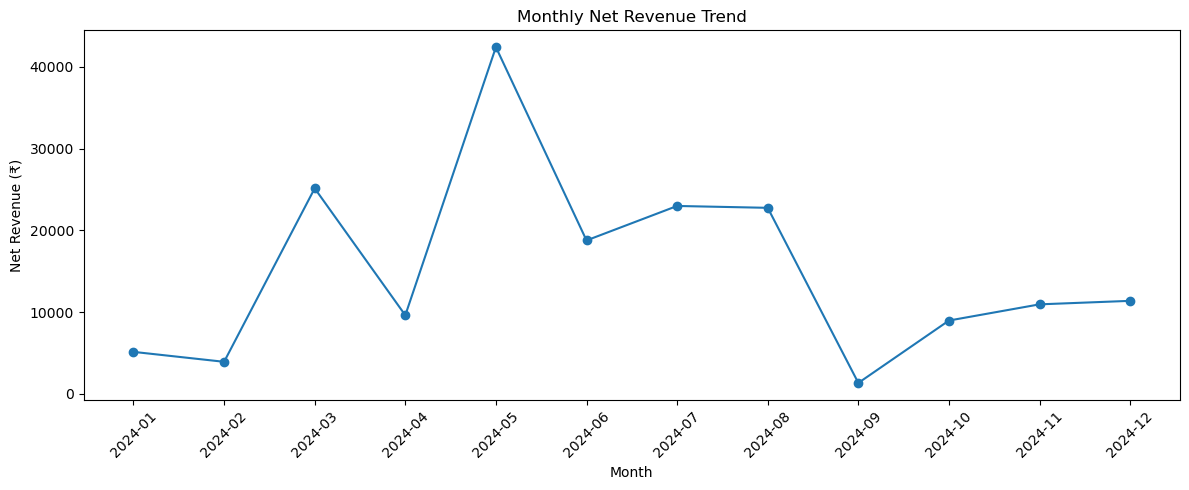

In [142]:
# MONTHLY REVENUE TREND CHART

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["order_month"],
    monthly_revenue["net_revenue"],
    marker="o"
)

plt.title("Monthly Net Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Net Revenue (₹)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#### Geographic Contribution

In [143]:
# GEOGRAPHIC CONTRIBUTION
# Revenue by Customer City

city_revenue = (
    filtered_df
    .groupby("city", as_index=False)
    .agg(
        net_revenue=("revenue", "sum"),
        orders=("order_id", "nunique"),
        units=("quantity", "sum")
    )
    .sort_values(
        "net_revenue",
        ascending=False
    )
)

city_revenue["revenue_share_pct"] = (
    city_revenue["net_revenue"]
    / city_revenue["net_revenue"].sum()
    * 100
)

city_revenue["net_revenue"] = city_revenue[
    "net_revenue"
].round(2)

city_revenue["revenue_share_pct"] = city_revenue[
    "revenue_share_pct"
].round(2)

city_revenue

,city,net_revenue,orders,units,revenue_share_pct
5,Jaipur,"42,862.84",10,34.00,23.38
4,Hyderabad,"34,803.84",8,27.00,18.98
2,Chennai,"18,784.80",7,17.00,10.24
9,Pune,"16,895.65",3,13.00,9.21
6,Kolkata,"14,013.53",7,14.00,7.64
7,Lucknow,"12,489.41",4,13.00,6.81
8,Mumbai,"12,259.62",4,8.00,6.69
0,Ahmedabad,"12,118.42",3,9.00,6.61
3,Delhi,"11,646.90",2,10.00,6.35
1,Bengaluru,"7,481.85",2,6.00,4.08


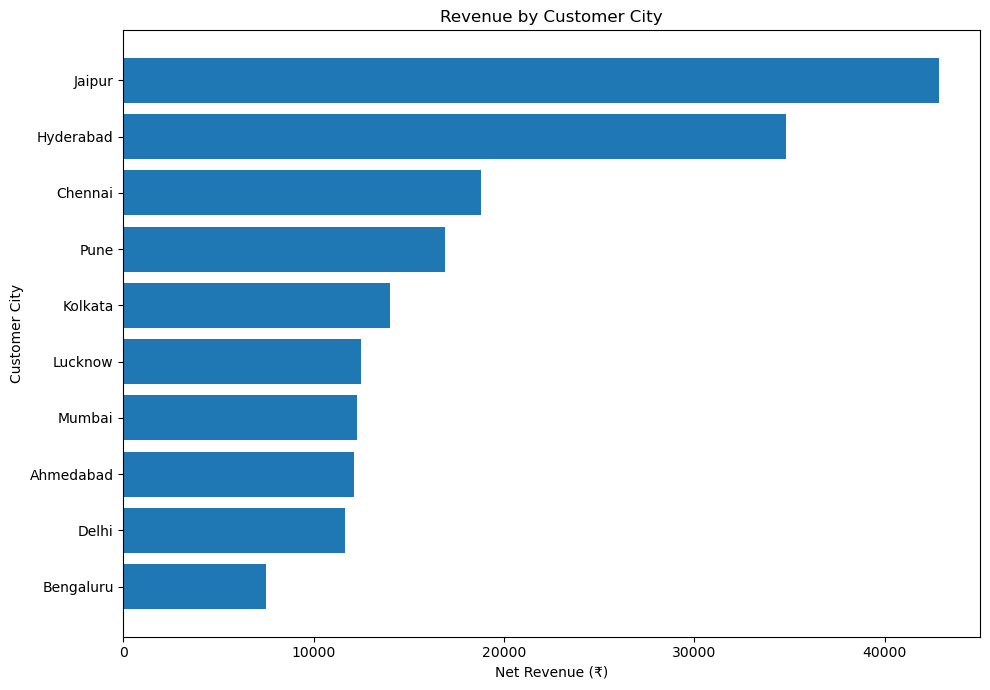

In [ ]:
# REVENUE BY CUSTOMER CITY

plt.figure(figsize=(10, 7))

plt.barh(
    city_revenue["city"].iloc[::-1],
    city_revenue["net_revenue"].iloc[::-1]
)

plt.title("Revenue by Customer City")
plt.xlabel("Net Revenue (₹)")
plt.ylabel("Customer City")

plt.tight_layout()
plt.show()

# TASK 3 : LLM-Powered HTML Dashboard

#### Prompt
You act as a Business Intelligence Analyst creating a single-page HTML dashboard for a D2C brand.

The manager wants a clear view of channel and product performance. The dashboard should feel like a real BI deliverable prepared for management, not a generic AI dashboard.

Use only the validated data given below. Do not invent numbers, transactions, products, cities, trends or business conclusions.

1. Overall KPIs

Show these at the top:

Orders: 50
Units: 151
Gross Value: ₹200,644.00
Total Discount: ₹17,287.14
Net Revenue: ₹183,356.86
Total Cost: ₹70,985.98
Gross Profit: ₹112,370.88
Average Discount: 9.36%
Gross Margin: 61.29%

The main KPI cards should highlight Net Revenue, Gross Profit, Gross Margin, Orders, Units and Average Discount.

2. Primary: Channel Performance

This is one of the most important sections.

Title:
Channel Performance

Subtitle:
Order volume and promotional intensity across selling channels

Orders by Channel:

App: 15
Instagram: 11
WhatsApp: 9
Website: 8
Amazon: 7

Use a horizontal bar chart. App should clearly appear first because it has the highest observed order volume.

Add Channel Discount Intensity:

Amazon: 7 orders, 17.43%
Instagram: 11 orders, 11.36%
Website: 8 orders, 9.25%
WhatsApp: 9 orders, 7.11%
App: 15 orders, 5.53%

Use a clean table or compact comparison chart.

A suitable insight is:
"App leads observed order volume with 15 orders, while Amazon has the highest observed average discount at 17.43%."

Do not claim which channel is most profitable because channel-level revenue and profit are not provided.

3. Primary: Product Performance

This is the other main section.

Title:
Product Performance

Subtitle:
Top products ranked by validated net revenue

Use a horizontal ranked bar chart with these values:

1. Vitamin C Serum: ₹30,730.35
2. Collagen Supplement: ₹20,429.18
3. Conditioner: ₹14,298.75
4. Ashwagandha: ₹14,100.00
5. Night Cream: ₹13,540.80
6. Moisturizer: ₹13,172.60
7. Hair Mask: ₹12,145.20
8. Vitamin D3: ₹10,751.58
9. Eyeliner: ₹10,709.26
10. Probiotic Blend: ₹10,605.76

Also show a small Top 10 Product Ranking table with the exact values.

Insight:
"Vitamin C Serum is the highest-revenue observed product at ₹30,730.35."

Do not call it the best product or make unsupported claims about future performance.

4. Category Economics

Use this as supporting context for the product story.

Validated data:

Wellness: ₹65,337.06, 35.63% share, AOV ₹4,083.57
Skincare: ₹64,722.59, 35.30% share, AOV ₹4,314.84
Haircare: ₹38,013.82, 20.73% share, AOV ₹2,715.27
Makeup: ₹15,283.39, 8.34% share, AOV ₹3,056.68

Use exactly ONE donut chart in the whole dashboard.

The donut should be:
Revenue Mix by Category

It should show the four category shares above.

This is the only place where a pie or donut chart should be used because there are only four categories and the business question is revenue composition.

Also show a horizontal bar chart for category revenue and a small metrics table with revenue, share and AOV.

Insight:
"Wellness and Skincare together contribute 70.93% of validated net revenue."

5. Supporting Analysis: Revenue Trend

Title:
Revenue Trend

Show monthly net revenue after discounts using a line chart.

Use the validated monthly revenue results from the notebook.

Do not invent monthly values.

The purpose is to show the observed movement in revenue over time. Do not claim seasonality or causality unless supported by the data.

6. Supporting Analysis: Geographic Contribution

Title:
Geographic Contribution

Show all 10 cities using a horizontal bar chart.

Jaipur: ₹42,862.84, 10 orders, 34 units, 23.38%
Hyderabad: ₹34,803.84, 8 orders, 27 units, 18.98%
Chennai: ₹18,784.80, 7 orders, 17 units, 10.24%
Pune: ₹16,895.65, 3 orders, 13 units, 9.21%
Kolkata: ₹14,013.53, 7 orders, 14 units, 7.64%
Lucknow: ₹12,489.41, 4 orders, 13 units, 6.81%
Mumbai: ₹12,259.62, 4 orders, 8 units, 6.69%
Ahmedabad: ₹12,118.42, 3 orders, 9 units, 6.61%
Delhi: ₹11,646.90, 2 orders, 10 units, 6.35%
Bengaluru: ₹7,481.85, 2 orders, 6 units, 4.08%

City revenue should reconcile to ₹183,356.86.

Insight:
"Jaipur is the largest individual city contributor at ₹42,862.84, representing 23.38% of revenue."

Use a bar chart and detailed table. Do not use a pie chart for cities.

7. Customer Context

If the validated notebook contains customer segment results, include them as a small supporting section.

Do not let customer analysis take attention away from channel and product performance.

8. Business Questions

Add a small section with predefined questions that a manager can click to see validated insights.

Examples:

What is the overall business performance?
Which channel has the highest discount?
What are the top revenue products?
Which category has the highest AOV?
What is driving revenue concentration?
Which city contributes the most revenue?

These should be predefined dashboard interactions only. Do not present the page as having a live LLM or AI connection.

9. Page Structure

Keep the dashboard on one page and use this order:

Header
KPI cards
Channel Performance
Product Performance
Category Economics
Revenue Trend
Geographic Contribution
Customer Context
Predefined Business Questions

Channel and Product Performance must receive the strongest visual emphasis because they are the main assignment requirement.

10. Design

Make it look like a polished business intelligence dashboard.

Use:
- clean white or light background
- professional typography
- dark text
- one restrained accent color
- consistent spacing
- clean cards
- clear chart titles
- readable tables
- aligned sections
- consistent currency and percentage formatting

Avoid:
- excessive colors
- unnecessary animations
- decorative graphics
- oversized headings
- too many cards
- clutter
- multiple pie charts

Use the right chart for the question:

Horizontal bar charts for ranking and comparison.
Line chart for revenue trend.
One donut chart for category revenue mix.
Tables for exact values.

11. Business Writing

Keep insights short and natural.

For example:

"App leads observed order volume with 15 orders."

"Amazon has the highest observed average discount at 17.43%."

"Vitamin C Serum is the highest-revenue observed product at ₹30,730.35."

"Wellness and Skincare together contribute 70.93% of validated net revenue."

Do not write unsupported recommendations or claims.

12. Technical Output

Generate exactly one standalone HTML file.

It must open directly in a browser and should not require the notebook, Excel files, CSV files or a backend.

All required validated data should be embedded in the HTML.

The dashboard should be responsive and work on desktop and smaller screens.

Before producing the final HTML, check that:
- the overall KPIs match the validated values
- all 5 channels are shown
- all 10 products are shown
- all 4 categories are shown
- all 10 cities are shown
- the revenue trend uses validated notebook data
- exactly one donut chart exists
- there is no fake "LLM Ready" label
- there is no live LLM input box
- the business questions are clearly predefined

The final dashboard should tell a simple business story:

Overall performance, then channel performance, then product performance, followed by category, trend and geographic context.

It should look like something a BI analyst would confidently present to a manager.



In [153]:
html_content = """
<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>D2C Channel + Product Performance | BI Command Center</title>
<style>
:root {
 --bg:#f4f6f8; --surface:#ffffff; --ink:#17202f; --muted:#667085; --line:#e4e8ee;
 --navy:#152238; --accent:#315efb; --accent2:#4f6df5; --green:#16835d;
 --amber:#b7791f; --red:#c2413b; --soft:#f7f9fc;
}
*{box-sizing:border-box}
body{margin:0;background:var(--bg);color:var(--ink);font-family:Inter,ui-sans-serif,system-ui,-apple-system,BlinkMacSystemFont,"Segoe UI",Arial,sans-serif}
.shell{max-width:1480px;margin:auto;padding:28px 30px 36px}
header{display:flex;justify-content:space-between;gap:24px;align-items:flex-start;margin-bottom:20px}
.eyebrow{font-size:10px;font-weight:800;letter-spacing:.14em;text-transform:uppercase;color:#667085}
h1{font-size:29px;line-height:1.05;margin:6px 0 7px;letter-spacing:-.035em}
.subtitle{color:var(--muted);font-size:12px}
.status{background:#fff;border:1px solid var(--line);border-radius:9px;padding:9px 12px;font-size:10px;font-weight:700;white-space:nowrap}
.status i{display:inline-block;width:7px;height:7px;border-radius:50%;background:#20a16a;margin-right:7px}
.filters{display:flex;gap:9px;flex-wrap:wrap;margin-bottom:14px}
.filter{background:#fff;border:1px solid var(--line);border-radius:8px;padding:7px 10px;color:var(--muted);font-size:10px}
.filter strong{color:var(--ink);margin-right:7px}
select{border:0;background:transparent;font-weight:700;color:var(--ink);outline:none}
.kpis{display:grid;grid-template-columns:repeat(7,1fr);gap:9px}
.card{background:var(--surface);border:1px solid var(--line);border-radius:11px;box-shadow:0 2px 8px rgba(16,24,40,.035)}
.kpi{padding:15px 15px 14px}
.k-label{font-size:9px;font-weight:800;color:var(--muted);letter-spacing:.07em;text-transform:uppercase}
.k-value{font-size:22px;font-weight:850;margin-top:9px;letter-spacing:-.025em}
.k-note{font-size:9px;color:#98a2b3;margin-top:4px}
.section{margin-top:24px}
.section-head{display:flex;align-items:end;justify-content:space-between;margin-bottom:9px}
.section-title{font-size:15px;font-weight:850;letter-spacing:-.01em}
.section-note{font-size:10px;color:var(--muted);margin-top:3px}
.badge{font-size:9px;font-weight:800;letter-spacing:.07em;background:#edf2ff;color:#3152c9;padding:5px 7px;border-radius:5px}
.grid2{display:grid;grid-template-columns:1.15fr .85fr;gap:12px}
.grid3{display:grid;grid-template-columns:repeat(3,1fr);gap:12px}
.panel{padding:17px}
.ptitle{font-size:12px;font-weight:800}
.psub{font-size:10px;color:var(--muted);margin:4px 0 14px}
.insight-grid{display:grid;grid-template-columns:repeat(3,1fr);gap:10px}
.insight{padding:14px;border-left:3px solid var(--accent)}
.insight h3{font-size:11px;margin:0 0 6px}
.insight .big{font-size:17px;font-weight:850}
.insight p{font-size:10px;line-height:1.5;color:#596579;margin:5px 0 0}
table{width:100%;border-collapse:collapse}
th{font-size:9px;text-transform:uppercase;letter-spacing:.05em;color:#98a2b3;text-align:left;padding:8px;border-bottom:1px solid var(--line)}
td{font-size:10.5px;padding:9px 8px;border-bottom:1px solid #eef1f5}
.r{text-align:right;font-weight:750}
.bar-row{display:grid;grid-template-columns:115px 1fr 78px;gap:10px;align-items:center;margin:12px 0}
.bar-label{font-size:10.5px;font-weight:700}
.bar-track{height:9px;border-radius:8px;background:#edf0f5;overflow:hidden}
.bar-fill{height:100%;border-radius:8px;background:var(--accent)}
.bar-value{font-size:10px;font-weight:800;text-align:right}
.trend svg{width:100%;height:auto;display:block}
.trend .grid{stroke:#edf0f5;stroke-width:1}
.trend .line{fill:none;stroke:var(--accent);stroke-width:3}
.trend .pt{fill:#fff;stroke:var(--accent);stroke-width:2}
.trend text{font-size:9px;fill:#98a2b3}
.trend .axis{font-size:8px}
.rank{display:grid;grid-template-columns:28px 1fr 90px;gap:8px;align-items:center;padding:8px 0;border-bottom:1px solid #eef1f5}
.rank:last-child{border-bottom:0}
.rankno{font-size:10px;color:#98a2b3;font-weight:800}
.rankname{font-size:10.5px;font-weight:700}
.rankval{font-size:10px;font-weight:800;text-align:right}
.callout{padding:12px;background:#f8fafc;border:1px solid var(--line);border-radius:8px;font-size:10px;line-height:1.5;color:#596579}
.callout b{color:var(--ink)}
.questions{display:grid;grid-template-columns:repeat(5,1fr);gap:8px}
.q{padding:12px;border:1px solid var(--line);border-radius:8px;background:#fff;font-size:10px;line-height:1.45}
.q span{display:block;color:#315efb;font-weight:850;font-size:9px;margin-bottom:5px}
.ai{background:var(--navy);color:#fff;border-radius:12px;padding:18px}
.ai-title{font-size:14px;font-weight:850}
.ai-sub{font-size:10px;color:#aeb9ca;margin-top:3px}
.chips{display:flex;gap:7px;flex-wrap:wrap;margin:13px 0 10px}
.chip{border:1px solid #3a4962;background:#202e45;color:#dce4f5;border-radius:6px;padding:7px 9px;font-size:9px;cursor:pointer}
.answer{background:#1d2a40;border:1px solid #35435c;border-radius:7px;padding:11px;color:#dce4f5;font-size:10px;line-height:1.55;min-height:42px}
.ask{display:flex;gap:7px;margin-top:8px}
.ask input{flex:1;border:1px solid #3a4962;background:#202e45;color:#fff;border-radius:7px;padding:9px;font-size:10px;outline:none}
.ask button{border:0;background:#fff;color:var(--navy);font-weight:850;border-radius:7px;padding:0 13px}
.footer{margin-top:22px;color:#98a2b3;font-size:9px;display:flex;justify-content:space-between;gap:15px}
.smallcaps{font-size:9px;text-transform:uppercase;letter-spacing:.06em;color:#98a2b3;font-weight:800}
@media(max-width:1100px){.kpis{grid-template-columns:repeat(4,1fr)}.grid2{grid-template-columns:1fr}.questions{grid-template-columns:repeat(3,1fr)}}
@media(max-width:760px){.shell{padding:18px}header{display:block}.status{display:inline-block;margin-top:12px}.kpis{grid-template-columns:repeat(2,1fr)}.grid3,.insight-grid,.questions{grid-template-columns:1fr}.bar-row{grid-template-columns:90px 1fr 65px}.footer{display:block}}

.pie-wrap{display:grid;grid-template-columns:180px 1fr;gap:18px;align-items:center;margin-top:6px}
.pie{width:170px;height:170px;border-radius:50%;background:conic-gradient(
 #315efb 0 23.38%, #4f6df5 23.38% 42.36%, #6b7ff2 42.36% 52.60%,
 #8492f0 52.60% 61.81%, #98a4ed 61.81% 69.45%, #aeb7ea 69.45% 76.26%,
 #c2c9e6 76.26% 82.95%, #d2d7e4 82.95% 89.56%, #e0e3e2 89.56% 95.91%,
 #eceeeb 95.91% 100%
);box-shadow:inset 0 0 0 1px rgba(0,0,0,.04)}
.legend{display:grid;grid-template-columns:1fr auto;gap:7px 10px}
.legend-item{font-size:9px;display:flex;align-items:center;gap:6px}
.dot{width:7px;height:7px;border-radius:50%;background:var(--accent)}
.legend-pct{font-size:9px;font-weight:800}
.chart-card{min-height:300px}


/* Assignment-aligned executive presentation layer */
.exec-hero{display:grid;grid-template-columns:1.15fr .85fr;gap:18px;align-items:stretch}
.exec-card{padding:20px 22px;border:1px solid #e5e7eb;border-radius:14px;background:#fff}
.exec-kicker{font-size:9px;letter-spacing:.14em;text-transform:uppercase;font-weight:800;color:#6b7280;margin-bottom:8px}
.exec-title{font-size:24px;line-height:1.12;font-weight:850;letter-spacing:-.025em;margin:0 0 8px}
.exec-sub{font-size:11px;color:#667085;line-height:1.55;max-width:720px}
.insight-grid{display:grid;grid-template-columns:repeat(3,1fr);gap:10px;margin-top:14px}
.insight{padding:12px;border-radius:10px;background:#f7f8fa;border:1px solid #eceef1}
.insight .v{font-size:17px;font-weight:850;margin-bottom:3px}
.insight .l{font-size:9px;color:#667085;line-height:1.4}
.priority{border-left:3px solid var(--accent);padding-left:10px}
.section-primary{margin-top:24px}
.section-primary .section-title{font-size:18px}
.section-primary .section-note{font-size:10px}
.section-number{display:inline-flex;width:22px;height:22px;border-radius:7px;align-items:center;justify-content:center;background:#eef2ff;color:#315efb;font-size:10px;font-weight:850;margin-right:8px}
.channel-grid{display:grid;grid-template-columns:1.05fr .95fr;gap:14px}
.product-grid{display:grid;grid-template-columns:1.15fr .85fr;gap:14px}
.callout-strong{font-size:11px;line-height:1.55}
@media(max-width:850px){.exec-hero,.channel-grid,.product-grid{grid-template-columns:1fr}.insight-grid{grid-template-columns:1fr}}


/* Final assignment presentation hierarchy */
.main-story{margin-top:18px}
.story-kicker{font-size:9px;letter-spacing:.14em;text-transform:uppercase;font-weight:850;color:#6b7280;margin:0 0 5px}
.story-title{font-size:19px;font-weight:850;letter-spacing:-.02em;margin:0}
.story-sub{font-size:10px;color:#667085;margin-top:4px;line-height:1.45}
.primary-grid{display:grid;grid-template-columns:1fr 1fr;gap:14px}
.primary-grid-wide{display:grid;grid-template-columns:1.15fr .85fr;gap:14px}
.chart-box{min-height:285px}
.chart-title{font-size:12px;font-weight:800;margin-bottom:3px}
.chart-note{font-size:9px;color:#667085;margin-bottom:13px}
.bar-chart{display:flex;flex-direction:column;gap:11px}
.hbar{display:grid;grid-template-columns:92px 1fr 72px;gap:9px;align-items:center}
.hbar-label{font-size:9px;font-weight:700;white-space:nowrap}
.hbar-track{height:16px;background:#eef0f3;border-radius:4px;overflow:hidden}
.hbar-fill{height:100%;border-radius:4px;background:#315efb}
.hbar-value{text-align:right;font-size:9px;font-weight:800}
.channel-takeaway{margin-top:15px;padding:10px 12px;background:#f7f8fa;border-left:3px solid #315efb;border-radius:7px;font-size:9px;line-height:1.5}
.product-chart{display:flex;flex-direction:column;gap:8px}
.product-row{display:grid;grid-template-columns:118px 1fr 78px;gap:8px;align-items:center}
.product-name{font-size:8.5px;font-weight:700;white-space:nowrap;overflow:hidden;text-overflow:ellipsis}
.product-track{height:14px;background:#eef0f3;border-radius:4px;overflow:hidden}
.product-fill{height:100%;background:#315efb;border-radius:4px}
.product-value{text-align:right;font-size:8.5px;font-weight:800}
.category-cards{display:grid;grid-template-columns:repeat(4,1fr);gap:10px}
.category-card{padding:13px;border:1px solid #e6e8eb;border-radius:10px;background:#fff}
.category-name{font-size:9px;font-weight:800}
.category-rev{font-size:16px;font-weight:850;margin:6px 0 2px}
.category-meta{font-size:8px;color:#667085}
.category-share{font-size:9px;font-weight:800;margin-top:7px}
@media(max-width:800px){
 .primary-grid,.primary-grid-wide{grid-template-columns:1fr}
 .category-cards{grid-template-columns:1fr 1fr}
}


.category-mix-wrap{display:grid;grid-template-columns:190px 1fr;gap:18px;align-items:center;min-height:235px}
.category-donut{
  width:180px;height:180px;border-radius:50%;
  background:conic-gradient(
    #315efb 0 35.63%,
    #6b7ff2 35.63% 70.93%,
    #98a4ed 70.93% 91.66%,
    #c9cee3 91.66% 100%
  );
  position:relative;
}
.category-donut:after{
  content:"Revenue\A Mix";
  white-space:pre;
  position:absolute;inset:38px;border-radius:50%;
  background:#fff;display:flex;align-items:center;justify-content:center;
  text-align:center;font-size:11px;font-weight:850;line-height:1.25;
}
.mix-legend{display:flex;flex-direction:column;gap:11px}
.mix-item{display:grid;grid-template-columns:10px 1fr auto;gap:7px;align-items:center;font-size:9px}
.mix-dot{width:9px;height:9px;border-radius:50%}
.mix-name{font-weight:750}
.mix-pct{font-weight:850}
@media(max-width:800px){.category-mix-wrap{grid-template-columns:1fr}.category-donut{margin:auto}}

</style>
</head>
<body>
<main class="shell">

<header>
 <div>
  <div class="eyebrow">D2C Commercial Intelligence</div>
  <h1>D2C Commercial Performance</h1>
  <div class="subtitle">Executive BI Dashboard · Revenue, Customers, Products &amp; 1 · Channel Performance</div>
 </div>
 <div class="status"><i></i>Validated Business View</div>
</header>

<div class="filters">
 <div class="filter"><strong>Category</strong><select><option>All Categories</option><option>Wellness</option><option>Skincare</option><option>Haircare</option><option>Makeup</option></select></div>
 <div class="filter"><strong>Channel</strong><select><option>All Channels</option><option>App</option><option>Website</option><option>Amazon</option><option>Instagram</option><option>WhatsApp</option></select></div>
 <div class="filter"><strong>Supporting Analysis · Customer Context</strong><select><option>All Segments</option><option>Gold</option><option>Silver</option><option>Bronze</option></select></div>
 <div class="filter" style="margin-left:auto"><span class="smallcaps">Scope</span>&nbsp; 50 orders · 151 units</div>
</div>

<section class="kpis">
 <div class="card kpi"><div class="k-label">Net Revenue</div><div class="k-value">₹183,356.86</div><div class="k-note">After discounts</div></div>
 <div class="card kpi"><div class="k-label">Orders</div><div class="k-value">50</div><div class="k-note">Observed transactions</div></div>
 <div class="card kpi"><div class="k-label">Units</div><div class="k-value">151</div><div class="k-note">Units sold</div></div>
 <div class="card kpi"><div class="k-label">AOV</div><div class="k-value">₹3,667.14</div><div class="k-note">Revenue / order</div></div>
 <div class="card kpi"><div class="k-label">Gross Profit</div><div class="k-value">₹112,370.88</div><div class="k-note">After product cost</div></div>
 <div class="card kpi"><div class="k-label">Gross Margin</div><div class="k-value">61.29%</div><div class="k-note">Profit / revenue</div></div>
 <div class="card kpi"><div class="k-label">Avg. Discount</div><div class="k-value">9.36%</div><div class="k-note">Observed discount rate</div></div>
</section>


<div class="main-story">
  <div class="story-kicker">Assignment Priority · Primary Analysis</div>
  <div class="story-title">Channel + Product Performance</div>
  <div class="story-sub">The core management view: where orders come from, how promotional intensity differs by channel, and which products contribute the most revenue.</div>

  <div class="primary-grid" style="margin-top:12px">
    <div class="card panel chart-box">
      <div class="chart-title">Orders by Channel</div>
      <div class="chart-note">Observed order volume across selling channels</div>
      <div class="bar-chart"><div class="hbar">
      <div class="hbar-label">App</div>
      <div class="hbar-track"><div class="hbar-fill" style="width:100.0%"></div></div>
      <div class="hbar-value">15 orders</div>
    </div><div class="hbar">
      <div class="hbar-label">Instagram</div>
      <div class="hbar-track"><div class="hbar-fill" style="width:73.3%"></div></div>
      <div class="hbar-value">11 orders</div>
    </div><div class="hbar">
      <div class="hbar-label">WhatsApp</div>
      <div class="hbar-track"><div class="hbar-fill" style="width:60.0%"></div></div>
      <div class="hbar-value">9 orders</div>
    </div><div class="hbar">
      <div class="hbar-label">Website</div>
      <div class="hbar-track"><div class="hbar-fill" style="width:53.3%"></div></div>
      <div class="hbar-value">8 orders</div>
    </div><div class="hbar">
      <div class="hbar-label">Amazon</div>
      <div class="hbar-track"><div class="hbar-fill" style="width:46.7%"></div></div>
      <div class="hbar-value">7 orders</div>
    </div></div>
      <div class="channel-takeaway"><b>Readout:</b> App leads observed order volume with 15 orders, followed by Instagram with 11.</div>
    </div>

    <div class="card panel chart-box">
      <div class="chart-title">Channel Discount Intensity</div>
      <div class="chart-note">Average observed discount by channel</div>
      <table>
        <tr><th>Channel</th><th class="r">Orders</th><th class="r">Avg. Discount</th></tr>
        <tr><td><b>Amazon</b></td><td class="r">7</td><td class="r"><b>17.43%</b></td></tr><tr><td><b>Instagram</b></td><td class="r">11</td><td class="r"><b>11.36%</b></td></tr><tr><td><b>Website</b></td><td class="r">8</td><td class="r"><b>9.25%</b></td></tr><tr><td><b>WhatsApp</b></td><td class="r">9</td><td class="r"><b>7.11%</b></td></tr><tr><td><b>App</b></td><td class="r">15</td><td class="r"><b>5.53%</b></td></tr>
      </table>
      <div class="channel-takeaway"><b>Readout:</b> Amazon has the highest observed average discount at 17.43%; App has the lowest at 5.53%.</div>
    </div>
  </div>

  <div class="primary-grid-wide" style="margin-top:14px">
    <div class="card panel chart-box">
      <div class="chart-title">Top Products by Revenue</div>
      <div class="chart-note">Validated net revenue ranking · top 10 observed products</div>
      <div class="product-chart"><div class="product-row">
      <div class="product-name">1. Vitamin C Serum</div>
      <div class="product-track"><div class="product-fill" style="width:100.0%"></div></div>
      <div class="product-value">₹30,730</div>
    </div><div class="product-row">
      <div class="product-name">2. Collagen Supplement</div>
      <div class="product-track"><div class="product-fill" style="width:66.5%"></div></div>
      <div class="product-value">₹20,429</div>
    </div><div class="product-row">
      <div class="product-name">3. Conditioner</div>
      <div class="product-track"><div class="product-fill" style="width:46.5%"></div></div>
      <div class="product-value">₹14,299</div>
    </div><div class="product-row">
      <div class="product-name">4. Ashwagandha</div>
      <div class="product-track"><div class="product-fill" style="width:45.9%"></div></div>
      <div class="product-value">₹14,100</div>
    </div><div class="product-row">
      <div class="product-name">5. Night Cream</div>
      <div class="product-track"><div class="product-fill" style="width:44.1%"></div></div>
      <div class="product-value">₹13,541</div>
    </div><div class="product-row">
      <div class="product-name">6. Moisturizer</div>
      <div class="product-track"><div class="product-fill" style="width:42.9%"></div></div>
      <div class="product-value">₹13,173</div>
    </div><div class="product-row">
      <div class="product-name">7. Hair Mask</div>
      <div class="product-track"><div class="product-fill" style="width:39.5%"></div></div>
      <div class="product-value">₹12,145</div>
    </div><div class="product-row">
      <div class="product-name">8. Vitamin D3</div>
      <div class="product-track"><div class="product-fill" style="width:35.0%"></div></div>
      <div class="product-value">₹10,752</div>
    </div><div class="product-row">
      <div class="product-name">9. Eyeliner</div>
      <div class="product-track"><div class="product-fill" style="width:34.8%"></div></div>
      <div class="product-value">₹10,709</div>
    </div><div class="product-row">
      <div class="product-name">10. Probiotic Blend</div>
      <div class="product-track"><div class="product-fill" style="width:34.5%"></div></div>
      <div class="product-value">₹10,606</div>
    </div></div>
    </div>

    <div class="card panel chart-box">
      <div class="chart-title">Top 10 Product Ranking</div>
      <div class="chart-note">Validated revenue values</div>
      <table>
        <tr><th>#</th><th>Product</th><th class="r">Revenue</th></tr>
        <tr><td>1</td><td><b>Vitamin C Serum</b></td><td class="r">₹30,730.35</td></tr><tr><td>2</td><td><b>Collagen Supplement</b></td><td class="r">₹20,429.18</td></tr><tr><td>3</td><td><b>Conditioner</b></td><td class="r">₹14,298.75</td></tr><tr><td>4</td><td><b>Ashwagandha</b></td><td class="r">₹14,100.00</td></tr><tr><td>5</td><td><b>Night Cream</b></td><td class="r">₹13,540.80</td></tr><tr><td>6</td><td><b>Moisturizer</b></td><td class="r">₹13,172.60</td></tr><tr><td>7</td><td><b>Hair Mask</b></td><td class="r">₹12,145.20</td></tr><tr><td>8</td><td><b>Vitamin D3</b></td><td class="r">₹10,751.58</td></tr><tr><td>9</td><td><b>Eyeliner</b></td><td class="r">₹10,709.26</td></tr><tr><td>10</td><td><b>Probiotic Blend</b></td><td class="r">₹10,605.76</td></tr>
      </table>
    </div>
  </div>

  <div style="margin-top:14px">
    <div class="story-kicker">Supporting Product Context</div>
    <div class="story-title" style="font-size:16px">Category Economics</div>
    <div class="story-sub">Category mix and AOV provide context for the product performance story.</div>
    <div class="category-cards" style="margin-top:10px"><div class="category-card">
      <div class="category-name">Wellness</div>
      <div class="category-rev">₹65,337</div>
      <div class="category-meta">AOV ₹4,083.57</div>
      <div class="category-share">35.63% revenue share</div>
    </div><div class="category-card">
      <div class="category-name">Skincare</div>
      <div class="category-rev">₹64,723</div>
      <div class="category-meta">AOV ₹4,314.84</div>
      <div class="category-share">35.30% revenue share</div>
    </div><div class="category-card">
      <div class="category-name">Haircare</div>
      <div class="category-rev">₹38,014</div>
      <div class="category-meta">AOV ₹2,715.27</div>
      <div class="category-share">20.73% revenue share</div>
    </div><div class="category-card">
      <div class="category-name">Makeup</div>
      <div class="category-rev">₹15,283</div>
      <div class="category-meta">AOV ₹3,056.68</div>
      <div class="category-share">8.34% revenue share</div>
    </div></div>
  </div>

  
<div class="primary-grid" style="margin-top:14px">
    <div class="card panel chart-box">
      <div class="chart-title">Revenue Mix by Category</div>
      <div class="chart-note">Share of validated net revenue · composition view</div>
      <div class="category-mix-wrap">
        <div class="category-donut" aria-label="Revenue mix donut chart"></div>
        <div class="mix-legend">
          <div class="mix-item"><span class="mix-dot" style="background:#315efb"></span><span class="mix-name">Wellness</span><span class="mix-pct">35.63%</span></div>
          <div class="mix-item"><span class="mix-dot" style="background:#6b7ff2"></span><span class="mix-name">Skincare</span><span class="mix-pct">35.30%</span></div>
          <div class="mix-item"><span class="mix-dot" style="background:#98a4ed"></span><span class="mix-name">Haircare</span><span class="mix-pct">20.73%</span></div>
          <div class="mix-item"><span class="mix-dot" style="background:#c9cee3"></span><span class="mix-name">Makeup</span><span class="mix-pct">8.34%</span></div>
          <div class="channel-takeaway"><b>Readout:</b> Wellness and Skincare together contribute 70.93% of validated net revenue.</div>
        </div>
      </div>
    </div>

    <div class="card panel chart-box">
      <div class="chart-title">Category Metrics</div>
      <div class="chart-note">Revenue, revenue share and AOV</div>
      <table>
        <tr><th>Category</th><th class="r">Revenue</th><th class="r">Share</th><th class="r">AOV</th></tr>
        <tr><td><b>Wellness</b></td><td class="r">₹65,337.06</td><td class="r"><b>35.63%</b></td><td class="r">₹4,083.57</td></tr>
        <tr><td><b>Skincare</b></td><td class="r">₹64,722.59</td><td class="r"><b>35.30%</b></td><td class="r">₹4,314.84</td></tr>
        <tr><td><b>Haircare</b></td><td class="r">₹38,013.82</td><td class="r">20.73%</td><td class="r">₹2,715.27</td></tr>
        <tr><td><b>Makeup</b></td><td class="r">₹15,283.39</td><td class="r">8.34%</td><td class="r">₹3,056.68</td></tr>
      </table>
    </div>
  </div>

</div>

<section class="section">
 <div class="section-head"><div><div class="section-title">Executive Readout</div><div class="section-note">What the current commercial mix says at a glance</div></div><span class="badge">MANAGEMENT VIEW</span></div>
 <div class="insight-grid">
  <div class="card insight"><h3>Revenue Concentration</h3><div class="big">70.93%</div><p>Wellness + Skincare share of observed revenue.</p></div>
  <div class="card insight"><h3>Category Economics</h3><div class="big">₹4,314.84</div><p>Skincare records the highest observed AOV.</p></div>
  <div class="card insight"><h3>Channel Pricing</h3><div class="big">17.43%</div><p>Amazon has the highest observed discount intensity.</p></div>
  <div class="card insight"><h3>Product Leader</h3><div class="big">₹30,730</div><p>Vitamin C Serum is the highest-revenue product.</p></div>
  <div class="card insight"><h3>Customer Volume</h3><div class="big">22 orders</div><p>Gold represents the largest observed segment volume.</p></div>
  <div class="card insight"><h3>Business Context</h3><div class="big">61.29%</div><p>Overall gross margin across the validated dataset.</p></div>
 </div>
</section>

<section class="section">
 <div class="section-head"><div><div class="section-title">Supporting Analysis · Revenue Trend</div><div class="section-note">Monthly net revenue after channel/product discounts</div></div><span class="badge">TIME SERIES</span></div>
 <div class="card panel trend">
  <div class="ptitle">Monthly Net Revenue</div>
  <div class="psub">The series reconciles to the validated total net revenue of ₹183,356.86.</div>
  <svg viewBox="0 0 820 280" role="img" aria-label="Monthly net revenue trend">
    <line x1="48" y1="20.0" x2="802" y2="20.0" class="grid"/><line x1="48" y1="73.8" x2="802" y2="73.8" class="grid"/><line x1="48" y1="127.5" x2="802" y2="127.5" class="grid"/><line x1="48" y1="181.2" x2="802" y2="181.2" class="grid"/><line x1="48" y1="235.0" x2="802" y2="235.0" class="grid"/><polyline points="48.0,209.0 116.5,215.2 185.1,107.6 253.6,186.3 322.2,20.0 390.7,139.9 459.3,118.5 527.8,119.7 596.4,228.3 664.9,189.6 733.5,179.5 802.0,177.4" class="line"/><circle cx="48.0" cy="209.0" r="4" class="pt"><title>Jan: ₹5,128.27</title></circle><circle cx="116.5" cy="215.2" r="4" class="pt"><title>Feb: ₹3,912.30</title></circle><circle cx="185.1" cy="107.6" r="4" class="pt"><title>Mar: ₹25,144.85</title></circle><circle cx="253.6" cy="186.3" r="4" class="pt"><title>Apr: ₹9,610.73</title></circle><circle cx="322.2" cy="20.0" r="4" class="pt"><title>May: ₹42,430.98</title></circle><circle cx="390.7" cy="139.9" r="4" class="pt"><title>Jun: ₹18,771.30</title></circle><circle cx="459.3" cy="118.5" r="4" class="pt"><title>Jul: ₹22,988.66</title></circle><circle cx="527.8" cy="119.7" r="4" class="pt"><title>Aug: ₹22,760.21</title></circle><circle cx="596.4" cy="228.3" r="4" class="pt"><title>Sep: ₹1,326.64</title></circle><circle cx="664.9" cy="189.6" r="4" class="pt"><title>Oct: ₹8,963.36</title></circle><circle cx="733.5" cy="179.5" r="4" class="pt"><title>Nov: ₹10,945.53</title></circle><circle cx="802.0" cy="177.4" r="4" class="pt"><title>Dec: ₹11,374.03</title></circle><text x="48.0" y="263" text-anchor="middle">Jan</text><text x="116.5" y="263" text-anchor="middle">Feb</text><text x="185.1" y="263" text-anchor="middle">Mar</text><text x="253.6" y="263" text-anchor="middle">Apr</text><text x="322.2" y="263" text-anchor="middle">May</text><text x="390.7" y="263" text-anchor="middle">Jun</text><text x="459.3" y="263" text-anchor="middle">Jul</text><text x="527.8" y="263" text-anchor="middle">Aug</text><text x="596.4" y="263" text-anchor="middle">Sep</text><text x="664.9" y="263" text-anchor="middle">Oct</text><text x="733.5" y="263" text-anchor="middle">Nov</text><text x="802.0" y="263" text-anchor="middle">Dec</text>
    <text x="5" y="25" class="axis">₹42K</text>
    <text x="5" y="132.5" class="axis">₹21K</text>
    <text x="5" y="240" class="axis">₹0</text>
    </svg>
 </div>
</section>

<section class="section">
 <div class="section-head"><div><div class="section-title">Category Context</div><div class="section-note">Revenue contribution and order economics</div></div><span class="badge">CATEGORY</span></div>
 <div class="grid2">
  <div class="card panel">
   <div class="ptitle">Revenue by Category</div><div class="psub">Sorted by net revenue</div>
   <div class="bar-row">
          <div class="bar-label">Wellness</div>
          <div class="bar-track"><div class="bar-fill" style="width:100.0%"></div></div>
          <div class="bar-value">₹65,337</div>
        </div><div class="bar-row">
          <div class="bar-label">Skincare</div>
          <div class="bar-track"><div class="bar-fill" style="width:99.1%"></div></div>
          <div class="bar-value">₹64,723</div>
        </div><div class="bar-row">
          <div class="bar-label">Haircare</div>
          <div class="bar-track"><div class="bar-fill" style="width:58.2%"></div></div>
          <div class="bar-value">₹38,014</div>
        </div><div class="bar-row">
          <div class="bar-label">Makeup</div>
          <div class="bar-track"><div class="bar-fill" style="width:23.4%"></div></div>
          <div class="bar-value">₹15,283</div>
        </div>
  </div>
  
<div class="card panel">
   <div class="ptitle">Category AOV</div><div class="psub">Average revenue per observed order</div>
   <table>
    <tr><th>Category</th><th>Orders</th><th class="r">AOV</th><th class="r">Share</th></tr>
    <tr><td><b>Wellness</b></td><td>16</td><td class="r">₹4,083.57</td><td class="r">35.63%</td></tr>
    <tr><td><b>Skincare</b></td><td>15</td><td class="r">₹4,314.84</td><td class="r">35.30%</td></tr>
    <tr><td>Haircare</td><td>14</td><td class="r">₹2,715.27</td><td class="r">20.73%</td></tr>
    <tr><td>Makeup</td><td>5</td><td class="r">₹3,056.68</td><td class="r">8.34%</td></tr>
   </table>
  </div>
 </div>
</section>

<section class="section">
 <div class="section-head"><div><div class="section-title">1 · Channel Performance</div><div class="section-note">Order volume alongside observed discount intensity</div></div><span class="badge">CHANNEL</span></div>
 <div class="grid2">
  <div class="card panel">
   <div class="ptitle">Order Volume</div><div class="psub">App leads observed transaction volume</div>
   <div class="bar-row">
          <div class="bar-label">App</div>
          <div class="bar-track"><div class="bar-fill" style="width:100.0%"></div></div>
          <div class="bar-value">₹15</div>
        </div><div class="bar-row">
          <div class="bar-label">Instagram</div>
          <div class="bar-track"><div class="bar-fill" style="width:73.3%"></div></div>
          <div class="bar-value">₹11</div>
        </div><div class="bar-row">
          <div class="bar-label">WhatsApp</div>
          <div class="bar-track"><div class="bar-fill" style="width:60.0%"></div></div>
          <div class="bar-value">₹9</div>
        </div><div class="bar-row">
          <div class="bar-label">Website</div>
          <div class="bar-track"><div class="bar-fill" style="width:53.3%"></div></div>
          <div class="bar-value">₹8</div>
        </div><div class="bar-row">
          <div class="bar-label">Amazon</div>
          <div class="bar-track"><div class="bar-fill" style="width:46.7%"></div></div>
          <div class="bar-value">₹7</div>
        </div>
  </div>
  <div class="card panel">
   <div class="ptitle">Discount Intensity</div><div class="psub">Highest observed does not imply worst performance</div>
   <table>
    <tr><th>Channel</th><th class="r">Orders</th><th class="r">Avg. Discount</th></tr>
    <tr><td><b>Amazon</b></td><td class="r">7</td><td class="r" style="color:var(--amber)">17.43%</td></tr>
    <tr><td>Instagram</td><td class="r">11</td><td class="r">11.36%</td></tr>
    <tr><td>Website</td><td class="r">8</td><td class="r">9.25%</td></tr>
    <tr><td>WhatsApp</td><td class="r">9</td><td class="r">7.11%</td></tr>
    <tr><td>App</td><td class="r">15</td><td class="r" style="color:var(--green)">5.53%</td></tr>
   </table>
  </div>
 </div>
</section>

<section class="section">
 <div class="section-head">
   <div><div class="section-title">Supporting Analysis · Geographic Contribution</div>
   <div class="section-note">Revenue by customer city in the selected slice</div></div>
   <span class="badge">GEOGRAPHY</span>
 </div>
 <div class="grid2">
  <div class="card panel">
   <div class="ptitle">Revenue by Customer City</div>
   <div class="psub">All 10 observed cities ranked by net revenue</div>
   <div class="bar-row"><div class="bar-label">Jaipur</div><div class="bar-track"><div class="bar-fill" style="width:100.0%"></div></div><div class="bar-value">₹42,863</div></div><div class="bar-row"><div class="bar-label">Hyderabad</div><div class="bar-track"><div class="bar-fill" style="width:81.2%"></div></div><div class="bar-value">₹34,804</div></div><div class="bar-row"><div class="bar-label">Chennai</div><div class="bar-track"><div class="bar-fill" style="width:43.8%"></div></div><div class="bar-value">₹18,785</div></div><div class="bar-row"><div class="bar-label">Pune</div><div class="bar-track"><div class="bar-fill" style="width:39.4%"></div></div><div class="bar-value">₹16,896</div></div><div class="bar-row"><div class="bar-label">Kolkata</div><div class="bar-track"><div class="bar-fill" style="width:32.7%"></div></div><div class="bar-value">₹14,014</div></div><div class="bar-row"><div class="bar-label">Lucknow</div><div class="bar-track"><div class="bar-fill" style="width:29.1%"></div></div><div class="bar-value">₹12,489</div></div><div class="bar-row"><div class="bar-label">Mumbai</div><div class="bar-track"><div class="bar-fill" style="width:28.6%"></div></div><div class="bar-value">₹12,260</div></div><div class="bar-row"><div class="bar-label">Ahmedabad</div><div class="bar-track"><div class="bar-fill" style="width:28.3%"></div></div><div class="bar-value">₹12,118</div></div><div class="bar-row"><div class="bar-label">Delhi</div><div class="bar-track"><div class="bar-fill" style="width:27.2%"></div></div><div class="bar-value">₹11,647</div></div><div class="bar-row"><div class="bar-label">Bengaluru</div><div class="bar-track"><div class="bar-fill" style="width:17.5%"></div></div><div class="bar-value">₹7,482</div></div>
  </div>
  
<div class="card panel">
   <div class="ptitle">City Contribution Detail</div>
   <div class="psub">Revenue, orders, units and share of total revenue</div>
   <table>
    <tr><th>City</th><th class="r">Revenue</th><th class="r">Orders</th><th class="r">Units</th><th class="r">Share</th></tr>
    <tr><td><b>Jaipur</b></td><td class="r">₹42,862.84</td><td class="r">10</td><td class="r">34</td><td class="r">23.38%</td></tr><tr><td><b>Hyderabad</b></td><td class="r">₹34,803.84</td><td class="r">8</td><td class="r">27</td><td class="r">18.98%</td></tr><tr><td><b>Chennai</b></td><td class="r">₹18,784.80</td><td class="r">7</td><td class="r">17</td><td class="r">10.24%</td></tr><tr><td><b>Pune</b></td><td class="r">₹16,895.65</td><td class="r">3</td><td class="r">13</td><td class="r">9.21%</td></tr><tr><td><b>Kolkata</b></td><td class="r">₹14,013.53</td><td class="r">7</td><td class="r">14</td><td class="r">7.64%</td></tr><tr><td><b>Lucknow</b></td><td class="r">₹12,489.41</td><td class="r">4</td><td class="r">13</td><td class="r">6.81%</td></tr><tr><td><b>Mumbai</b></td><td class="r">₹12,259.62</td><td class="r">4</td><td class="r">8</td><td class="r">6.69%</td></tr><tr><td><b>Ahmedabad</b></td><td class="r">₹12,118.42</td><td class="r">3</td><td class="r">9</td><td class="r">6.61%</td></tr><tr><td><b>Delhi</b></td><td class="r">₹11,646.90</td><td class="r">2</td><td class="r">10</td><td class="r">6.35%</td></tr><tr><td><b>Bengaluru</b></td><td class="r">₹7,481.85</td><td class="r">2</td><td class="r">6</td><td class="r">4.08%</td></tr>
   </table>
   <div class="callout" style="margin-top:12px">
    <b>Geographic readout:</b> Jaipur is the largest individual city contributor
    at ₹42,862.84 (23.38%), followed by Hyderabad at ₹34,803.84 (18.98%).
    The ten cities collectively account for the full validated revenue of ₹183,356.86.
   </div>
  </div>
 </div>
</section>
<section class="section">
 <div class="section-head"><div><div class="section-title">2 · Product Performance</div><div class="section-note">Ranked by validated net revenue</div></div><span class="badge">PRODUCT</span></div>
 <div class="grid2">
  <div class="card panel">
   <div class="ptitle">Top 10 Product Ranking</div><div class="psub">Revenue contribution across the leading products</div>
   <div class="rank"><div class="rankno">#1</div><div class="rankname">Vitamin C Serum</div><div class="rankval">₹30,730.35</div></div><div class="rank"><div class="rankno">#2</div><div class="rankname">Collagen Supplement</div><div class="rankval">₹20,429.18</div></div><div class="rank"><div class="rankno">#3</div><div class="rankname">Conditioner</div><div class="rankval">₹14,298.75</div></div><div class="rank"><div class="rankno">#4</div><div class="rankname">Ashwagandha</div><div class="rankval">₹14,100.00</div></div><div class="rank"><div class="rankno">#5</div><div class="rankname">Night Cream</div><div class="rankval">₹13,540.80</div></div><div class="rank"><div class="rankno">#6</div><div class="rankname">Moisturizer</div><div class="rankval">₹13,172.60</div></div><div class="rank"><div class="rankno">#7</div><div class="rankname">Hair Mask</div><div class="rankval">₹12,145.20</div></div><div class="rank"><div class="rankno">#8</div><div class="rankname">Vitamin D3</div><div class="rankval">₹10,751.58</div></div><div class="rank"><div class="rankno">#9</div><div class="rankname">Eyeliner</div><div class="rankval">₹10,709.26</div></div><div class="rank"><div class="rankno">#10</div><div class="rankname">Probiotic Blend</div><div class="rankval">₹10,605.76</div></div>
  </div>
  <div class="card panel">
   <div class="ptitle">Supporting Analysis · Customer Context</div><div class="psub">Observed order volume and average MRP</div>
   <table>
    <tr><th>Segment</th><th class="r">Orders</th><th class="r">Avg. MRP</th></tr>
    <tr><td><b>Gold</b></td><td class="r">22</td><td class="r">₹1,327.64</td></tr>
    <tr><td>Silver</td><td class="r">18</td><td class="r">₹1,282.11</td></tr>
    <tr><td>Bronze</td><td class="r">10</td><td class="r">₹1,282.90</td></tr>
   </table>
   <div class="callout" style="margin-top:13px"><b>Customer mix:</b> Gold represents the largest observed order volume. No customer motivation or loyalty behavior is inferred from this metric alone.</div>
  </div>
 </div>
</section>

<section class="section">
 <div class="section-head"><div><div class="section-title">Management Questions</div><div class="section-note">Analytical questions surfaced by the current evidence</div></div></div>
 <div class="questions">
  <div class="q"><span>01 · CATEGORY</span>What is driving the high AOV observed in Skincare?</div>
  <div class="q"><span>02 · PRICING</span>Is the higher discount intensity on Amazon associated with different order economics?</div>
  <div class="q"><span>03 · PRODUCT</span>How concentrated is revenue within the top products?</div>
  <div class="q"><span>04 · GROWTH</span>Can the Wellness category sustain its current revenue contribution?</div>
  <div class="q"><span>05 · CATEGORY</span>What explains the lower AOV observed in Haircare?</div>
 </div>
</section>

<section class="section">
 <div class="section-head"><div><div class="section-title">Business Insights</div><div class="section-note">Select a predefined question to explore the commercial performance</div></div></div>
 <div class="ai">
  <div class="ai-title">Commercial performance insights</div>
  <div class="ai-sub">Select a question below to view a predefined business insight based on the validated dashboard data.</div>
  <div class="chips">
   <button class="chip" data-q="summary">Executive summary</button>
   <button class="chip" data-q="revenue">What is driving revenue?</button>
   <button class="chip" data-q="aov">Which category has the highest AOV?</button>
   <button class="chip" data-q="discount">Which channel has the highest discount?</button>
   <button class="chip" data-q="products">What are the top revenue products?</button>
   <button class="chip" data-q="management">What should management investigate?</button>
  </div>
  <div class="answer" id="answer">Select a question above for a concise BI readout.</div>
  
 </div>
</section>

<div class="footer">
 <span>D2C Channel & Product Performance Dashboard · Metrics based on validated transaction analysis</span>
 <span>50 orders · 151 units · ₹183,356.86 net revenue</span>
</div>
</main>

<script>
const answers = {
 summary:"The observed business generated ₹183,356.86 in net revenue across 50 orders and 151 units, with ₹112,370.88 gross profit and a 61.29% gross margin. Wellness and Skincare together account for 70.93% of revenue. App leads observed order volume, while Amazon has the highest observed discount intensity.",
 revenue:"Wellness contributes the highest category revenue at ₹65,337.06 (35.63%), followed closely by Skincare at ₹64,722.59 (35.30%). Vitamin C Serum is the highest-revenue product at ₹30,730.35.",
 aov:"Skincare has the highest observed AOV at ₹4,314.84, followed by Wellness at ₹4,083.57.",
 discount:"Amazon has the highest observed average discount at 17.43%, while App has the lowest at 5.53%. The available data does not establish that discount intensity caused channel performance differences.",
 products:"Vitamin C Serum leads at ₹30,730.35, followed by Collagen Supplement at ₹20,429.18 and Conditioner at ₹14,298.75.",
 management:"The current evidence suggests five areas for investigation: the drivers of Skincare AOV, Amazon discount economics, product revenue concentration, the sustainability of Wellness contribution, and the lower observed Haircare AOV."
};
document.querySelectorAll(".chip").forEach(b=>b.addEventListener("click",()=>document.getElementById("answer").textContent=answers[b.dataset.q]));
function askQuestion(){
 const q=document.getElementById("question").value.toLowerCase();
 let k=q.includes("discount")?"discount":q.includes("aov")?"aov":q.includes("product")?"products":q.includes("management")||q.includes("investigate")?"management":q.includes("revenue")||q.includes("driver")?"revenue":"summary";
 document.getElementById("answer").textContent=answers[k];
}
</script>
</body></html>
"""

In [154]:
dashboard_file = "d2c_dashboard.html"

with open(dashboard_file, "w", encoding="utf-8") as f:
    f.write(html_content)

In [156]:
from IPython.display import HTML, display
from pathlib import Path

dashboard_path = Path("d2c_dashboard.html")

dashboard_path.write_text(
    html_content,
    encoding="utf-8"
)

display(HTML(f"""
<div style="padding:20px;">
    <h3>Final HTML Dashboard</h3>

    <a href="{dashboard_path.name}" target="_blank"
       style="
       display:inline-block;
       padding:12px 20px;
       background:#1f4ed8;
       color:white;
       text-decoration:none;
       border-radius:6px;
       font-weight:600;
       ">
       Open D2C Business Intelligence Dashboard →
    </a>
</div>
"""))

In [158]:
import webbrowser
from pathlib import Path
from IPython.display import display, Markdown

dashboard_path = Path("d2c_dashboard.html").resolve()

print("Dashboard:", dashboard_path)

# Create a clickable-looking link in the notebook
display(Markdown(
    f"### [Open D2C Business Intelligence Dashboard](file:///{dashboard_path.as_posix()})"
))

Dashboard: C:\Users\KIIT\OneDrive\Desktop\BI_Assignment\notebooks\d2c_dashboard.html


### [Open D2C Business Intelligence Dashboard](file:///C:/Users/KIIT/OneDrive/Desktop/BI_Assignment/notebooks/d2c_dashboard.html)